# HW3 — Quantile Strategies on Financial Ratios
**Name:** Malank Goel  
**Student ID:** 12350684

This notebook builds an investable universe (Jan 2018–Jun 2023), constructs three financial ratios from Zacks datasets, and evaluates quantile long–short strategies on (i) ratio **levels** and (ii) ratio **changes**, at monthly and weekly rebalance frequencies.

## Investable Universe Checklist
I assemble the investable universe for January 2018 through June 2023 and I want each requirement verified without running every cell. I state each requirement in prose and show the logic that enforces it. My plan is to map tickers first then apply price coverage market value leverage and sector filters and finish with ratio feasibility checks before summarizing counts.

In [69]:
import pandas as pd
import numpy as np
from collections import defaultdict
from pathlib import Path
import re
import matplotlib.pyplot as plt
from pandas.tseries.offsets import BDay


pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 200)

START_DATE = pd.Timestamp("2018-01-01")
END_DATE = pd.Timestamp("2023-06-30")
RECENT_CUTOFF = END_DATE - pd.DateOffset(years=1)
PRICE_COVERAGE_THRESHOLD = 1.0
MIN_FR_UNIQUE_YEARS = 5

EXCLUDED_SECTORS = {"AUTOMOTIVE", "FINANCIAL", "INSURANCE"}

paths = {
    "fc": Path("ZACKS_FC_2_76e4bece47ce87cb8f221f639c7f829b.csv"),
    "fr": Path("ZACKS_FR_2_f40c6a304f87d9f492c1f21839d474e2.csv"),
    "mt": Path("ZACKS_MT_2_5c2afb6368dcc3ed48e1a84279323e63.csv"),
    "mktv": Path("ZACKS_MKTV_2_ecb7f768974bbdd26964caefe2fd0378.csv"),
    "hdm": Path("ZACKS_HDM_2_5035a21ce4e45c8e7fbda0facdcfcb6c.csv"),
    "qm_prices": Path("QUOTEMEDIA_PRICES_247f636d651d8ef83d8ca1e756cf5ee4.csv"),
}

### Helper utilities
I define small helper functions so later cells are easier to read and review.

In [70]:
def clean_ticker(series: pd.Series) -> pd.Series:
    return series.astype(str).str.strip().str.upper()

def as_dt(series: pd.Series) -> pd.Series:
    return pd.to_datetime(series, errors="coerce")

def numeric(series: pd.Series | float) -> pd.Series:
    return pd.to_numeric(series, errors="coerce")

def ensure_series(df: pd.DataFrame, col: str) -> pd.Series:
    if col not in df.columns:
        return pd.Series(np.nan, index=df.index, dtype="float64")
    return numeric(df[col])

### QuoteMedia ticker to Zacks mapping
I map QuoteMedia tickers to Zacks identifiers so prices and filings can be joined cleanly.

In [71]:
hdm = pd.read_csv(paths["hdm"], usecols=["ticker", "m_ticker"], low_memory=False)
hdm["ticker_clean"] = clean_ticker(hdm["ticker"])
hdm["m_ticker_clean"] = clean_ticker(hdm["m_ticker"])
hdm = (hdm.dropna(subset=["ticker_clean", "m_ticker_clean"])          .drop_duplicates(subset=["ticker_clean"], keep="last"))

### Prices require full coverage January 2018 through June 2023 and at least 200 tickers
I require complete daily price coverage over the assignment window and keep only tickers with no gaps. I also confirm the surviving universe meets the minimum size requirement.

In [72]:
CHUNK_ROWS = 250_000
unique_price_days: set[pd.Timestamp] = set()
ticker_days: dict[str, set[pd.Timestamp]] = defaultdict(set)

for chunk in pd.read_csv(
    paths["qm_prices"],
    usecols=["ticker", "date", "adj_close"],
    parse_dates=["date"],
    chunksize=CHUNK_ROWS,
):
    chunk = chunk[(chunk["date"] >= START_DATE) & (chunk["date"] <= END_DATE)].copy()
    if chunk.empty:
        continue

    chunk["ticker_clean"] = clean_ticker(chunk["ticker"])
    chunk = chunk.merge(
        hdm[["ticker_clean", "m_ticker_clean"]],
        on="ticker_clean",
        how="left",
    ).dropna(subset=["m_ticker_clean"])
    chunk["m_ticker_clean"] = clean_ticker(chunk["m_ticker_clean"])
    chunk["date"] = chunk["date"].dt.normalize()

    unique_price_days.update(chunk["date"].unique())

    daily_obs = chunk[["m_ticker_clean", "date"]].drop_duplicates()
    for ticker, dates in daily_obs.groupby("m_ticker_clean")["date"]:
        ticker_days[ticker].update(dates.tolist())

trading_days = len(unique_price_days)
full_coverage_ids = {
    ticker for ticker, days in ticker_days.items()
    if len(days) == trading_days
}

if len(full_coverage_ids) < 200:
    raise ValueError("Need at least 200 tickers with complete pricing coverage.")

### Market value floor with MKTV never below 100 million
I apply the market value floor required by the assignment and drop any ticker that dips below it at any time.

In [73]:
mktv = pd.read_csv(
    paths["mktv"],
    usecols=["m_ticker", "per_end_date", "mkt_val", "active_ticker_flag"],
    parse_dates=["per_end_date"],
    low_memory=False,
)
mktv = mktv.rename(columns={"per_end_date": "date", "mkt_val": "mktval"})
mktv["m_ticker_clean"] = clean_ticker(mktv["m_ticker"])
mktv["mktval"] = pd.to_numeric(mktv["mktval"], errors="coerce")
mktv = mktv[(mktv["date"] >= START_DATE) & (mktv["date"] <= END_DATE)]

mktv_subset = mktv[mktv["m_ticker_clean"].isin(full_coverage_ids)].copy()
mktv_subset = mktv_subset.dropna(subset=["m_ticker_clean", "date", "mktval"])

mktv_min = mktv_subset.groupby("m_ticker_clean")["mktval"].min()
validated_floor_ids = set(mktv_min[mktv_min >= 100].index)

# IMPORTANT: do not pass tickers with missing MKTV — floor is defined using MKTV.
base_universe_ids = validated_floor_ids

print("Price full coverage tickers:", len(full_coverage_ids))
print("Tickers with MKTV data in window:", mktv_subset["m_ticker_clean"].nunique())
print("After $100MM MKTV floor:", len(base_universe_ids))

Price full coverage tickers: 4044
Tickers with MKTV data in window: 2356
After $100MM MKTV floor: 1619


### Debt to market cap filter with ratio at least 0.1 at least once
I keep tickers that reach the required debt to market cap threshold at least once during the window.

In [74]:
fc = pd.read_csv(
    paths["fc"],
    usecols=["m_ticker", "per_end_date", "tot_liab", "tot_lterm_debt", "curr_portion_debt", "net_curr_debt", "net_lterm_debt"],
    parse_dates=["per_end_date"],
    low_memory=False,
)
fc = fc.rename(columns={"per_end_date": "date"})
fc["m_ticker_clean"] = clean_ticker(fc["m_ticker"])
fc = fc[(fc["date"] >= START_DATE) & (fc["date"] <= END_DATE)]
fc = fc[fc["m_ticker_clean"].isin(base_universe_ids)].copy()

net_curr = ensure_series(fc, "net_curr_debt").fillna(0)
net_lterm = ensure_series(fc, "net_lterm_debt").fillna(0)
lt_debt = ensure_series(fc, "tot_lterm_debt").fillna(0)
curr_portion = ensure_series(fc, "curr_portion_debt").fillna(0)
tot_liab = ensure_series(fc, "tot_liab")

net_debt = net_curr + net_lterm
book_debt = lt_debt + curr_portion
fc["debt"] = tot_liab
fallback = fc["debt"].isna()
fc.loc[fallback, "debt"] = net_debt[fallback]
fc.loc[fallback & fc["debt"].isna(), "debt"] = book_debt[fallback]
fc["debt"] = fc["debt"].fillna(0)

mktv_for_join = mktv[["m_ticker_clean", "date", "mktval"]].copy()
debt_panel = fc.merge(mktv_for_join, on=["m_ticker_clean", "date"], how="left")
debt_panel = debt_panel.dropna(subset=["mktval"])
debt_panel["debt_to_mktcap"] = debt_panel["debt"] / debt_panel["mktval"]

max_debt_ratio = debt_panel.groupby("m_ticker_clean")["debt_to_mktcap"].max()
debt_filter_ids = set(
    max_debt_ratio.loc[lambda s: s > 0.1].index
)

### Sector exclusions for Automotive Financial Insurance
I remove the excluded sectors so the universe aligns with the instructions.

In [75]:
mt = pd.read_csv(
    paths["mt"],
    usecols=["m_ticker", "active_ticker_flag", "zacks_x_sector_desc", "zacks_x_ind_desc"],
    low_memory=False,
)
mt["m_ticker_clean"] = clean_ticker(mt["m_ticker"])
mt = mt[mt["active_ticker_flag"] == "Y"].copy()
mt = mt[mt["m_ticker_clean"].isin(debt_filter_ids)].copy()

mt["sector_desc"] = mt["zacks_x_sector_desc"].fillna("").str.upper()
mt["industry_desc"] = mt["zacks_x_ind_desc"].fillna("").str.upper()

auto_pattern = r"AUTO|TIRE|TRUCK"
finance_pattern = r"BANK|LEND|FINANCE|BROKER|CAPITAL MARKETS|SECURIT|ASSET MGMT"
insurance_pattern = r"INSURANCE"

mt["is_excluded"] = (
    mt["industry_desc"].str.contains(auto_pattern, regex=True) |
    mt["industry_desc"].str.contains(finance_pattern, regex=True) |
    mt["industry_desc"].str.contains(insurance_pattern, regex=True)
)

sector_keep_ids = set(mt.loc[~mt["is_excluded"], "m_ticker_clean"].unique())

### Ratio feasibility with FR coverage and recency
I require at least five distinct years of FR data and at least one report within the prior 12 months so the ratios are both computable and reasonably current.

In [76]:
fr = pd.read_csv(
    paths["fr"],
    usecols=["m_ticker", "per_end_date", "ret_invst"],
    parse_dates=["per_end_date"],
    low_memory=False,
)
fr = fr.rename(columns={"per_end_date": "date"})
fr["m_ticker_clean"] = clean_ticker(fr["m_ticker"])
fr = fr[(fr["date"] >= START_DATE) & (fr["date"] <= END_DATE)]
fr = fr[fr["m_ticker_clean"].isin(sector_keep_ids)].copy()
fr["ret_invst"] = pd.to_numeric(fr["ret_invst"], errors="coerce")

fr_years = fr.groupby("m_ticker_clean")["date"].apply(lambda s: s.dt.year.nunique())
fr_last = fr.groupby("m_ticker_clean")["date"].max()
fr_has_ret = fr.groupby("m_ticker_clean")["ret_invst"].apply(lambda s: s.notna().any())

fr_ready = set(fr_years[(fr_years >= MIN_FR_UNIQUE_YEARS)].index)
fr_ready = {t for t in fr_ready if (fr_last.get(t, pd.Timestamp.min) >= RECENT_CUTOFF) and bool(fr_has_ret.get(t, False))}

fc_cols = pd.read_csv(paths["fc"], nrows=0, low_memory=False).columns.tolist()

need = ["m_ticker","per_end_date",
        "tot_liab","tot_lterm_debt","curr_portion_debt","net_curr_debt","net_lterm_debt",
        "eps_diluted_net","eps_diluted_parent_comp","eps_basic_net","basic_net_eps"]
usecols = [c for c in need if c in fc_cols]

fc_chk = pd.read_csv(
    paths["fc"],
    usecols=usecols,
    parse_dates=["per_end_date"],
    low_memory=False,
)
fc_chk = fc_chk.rename(columns={"per_end_date": "date"})
fc_chk["m_ticker_clean"] = clean_ticker(fc_chk["m_ticker"])
fc_chk = fc_chk[(fc_chk["date"] >= START_DATE) & (fc_chk["date"] <= END_DATE)]
fc_chk = fc_chk[fc_chk["m_ticker_clean"].isin(sector_keep_ids)].copy()

for c in [col for col in fc_chk.columns if col not in {"m_ticker","m_ticker_clean","date"}]:
    fc_chk[c] = pd.to_numeric(fc_chk[c], errors="coerce")

fc_years = fc_chk.groupby("m_ticker_clean")["date"].apply(lambda s: s.dt.year.nunique())
fc_last = fc_chk.groupby("m_ticker_clean")["date"].max()

debt_candidates = [c for c in ["tot_liab","net_curr_debt","net_lterm_debt","tot_lterm_debt","curr_portion_debt"] if c in fc_chk.columns]
eps_candidates  = [c for c in ["eps_diluted_net","eps_diluted_parent_comp","eps_basic_net","basic_net_eps"] if c in fc_chk.columns]

fc_has_debt = fc_chk.groupby("m_ticker_clean")[debt_candidates].apply(lambda df: df.notna().any().any()) if debt_candidates else pd.Series(False, dtype=bool)
fc_has_eps  = fc_chk.groupby("m_ticker_clean")[eps_candidates].apply(lambda df: df.notna().any().any()) if eps_candidates else pd.Series(False, dtype=bool)

fc_ready = set(fc_years[(fc_years >= MIN_FR_UNIQUE_YEARS)].index)
fc_ready = {
    t for t in fc_ready
    if (fc_last.get(t, pd.Timestamp.min) >= RECENT_CUTOFF)
    and bool(fc_has_debt.get(t, False))
    and bool(fc_has_eps.get(t, False))
}

final_universe_ids = sorted(set(base_universe_ids).intersection(fr_ready).intersection(fc_ready))

print("After sector filter:", len(sector_keep_ids))
print("FR ready (ret_invst):", len(fr_ready))
print("FC ready (debt + EPS):", len(fc_ready))
print("Final universe after ratio feasibility:", len(final_universe_ids))

After sector filter: 1199
FR ready (ret_invst): 1198
FC ready (debt + EPS): 1198
Final universe after ratio feasibility: 1198


### Summary diagnostics
I summarize counts after each filter so I can confirm that each requirement is applied as intended and to track how much the universe shrinks at each step.

In [77]:
stage_counts = {
    "price_full_coverage": len(full_coverage_ids),
    "after_100mm_floor": len(base_universe_ids),
    "after_debt_gt_0p1": len(debt_filter_ids),
    "after_sector_exclusions": len(sector_keep_ids),
    "ratio_feasible_final": len(final_universe_ids),
}

stage_counts

{'price_full_coverage': 4044,
 'after_100mm_floor': 1619,
 'after_debt_gt_0p1': 1436,
 'after_sector_exclusions': 1199,
 'ratio_feasible_final': 1198}

## Section 4 Select Financial Ratios
I construct debt to market cap return on investment and price to earnings from raw filings and align them to a daily grid for the investable universe. I treat each filing as effective on the next business day to avoid look ahead bias and to match the assignment rule.

I follow a three step workflow. I first isolate the tickers that passed the universe filters. I then compute the three ratios directly from Zacks filings. I finally align each filing to daily prices by applying the next business day effectiveness rule.

In [78]:
_ticker_re = re.compile(r"[^A-Z0-9]+")

def clean_ticker(x):
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return np.nan
    s = str(x).strip().upper()
    if s == "" or s == "NAN":
        return np.nan
    s = s.lstrip("#")
    s = _ticker_re.sub("", s)
    return s if s != "" else np.nan

SECTION4_START = pd.Timestamp("2018-01-01")
SECTION4_END   = pd.Timestamp("2023-06-30")

SECTION4_PRICE_CHUNKSIZE = 600_000
SECTION4_MIN_RATIOS = 3



### 4.1 Universe coverage and daily prices
I keep the tickers that passed the universe tests and include WM for the worked example. I map them to QuoteMedia tickers and pull only the price history needed for this section.

In [79]:
section4_ids = sorted(set(clean_ticker(t) for t in final_universe_ids if clean_ticker(t) == clean_ticker(t)))

hdm_map = (
    pd.read_csv(paths["hdm"], usecols={"ticker", "m_ticker"}, low_memory=False)
    .assign(
        q_ticker_clean=lambda df: df["ticker"].map(clean_ticker),
        m_ticker_clean=lambda df: df["m_ticker"].map(clean_ticker),
    )
    .dropna(subset=["q_ticker_clean", "m_ticker_clean"])
    .drop_duplicates(subset=["m_ticker_clean"], keep="last")
)

section4_map = hdm_map[hdm_map["m_ticker_clean"].isin(section4_ids)].copy()
missing_map = sorted(set(section4_ids) - set(section4_map["m_ticker_clean"]))
if missing_map:
    print(f"{len(missing_map)} tickers missing QuoteMedia mapping (first five shown): {missing_map[:5]}")

def load_prices_for_map(mapping: pd.DataFrame) -> pd.DataFrame:
    if mapping.empty:
        raise ValueError("No tickers with QuoteMedia coverage for Section 4.")
    q_tickers = set(mapping["q_ticker_clean"])
    frames = []
    for chunk in pd.read_csv(
        paths["qm_prices"],
        usecols=["ticker", "date", "adj_close"],
        parse_dates=["date"],
        chunksize=SECTION4_PRICE_CHUNKSIZE,
        low_memory=False,
    ):
        chunk["q_ticker_clean"] = chunk["ticker"].map(clean_ticker)
        chunk = chunk[chunk["q_ticker_clean"].isin(q_tickers)]
        if chunk.empty:
            continue
        chunk = chunk.merge(mapping[["q_ticker_clean", "m_ticker_clean"]], on="q_ticker_clean", how="left")
        chunk = chunk.dropna(subset=["m_ticker_clean", "date"])
        frames.append(chunk[["m_ticker_clean", "date", "adj_close"]])
    if not frames:
        raise ValueError("Price file contained none of the Section 4 tickers.")
    prices = pd.concat(frames, ignore_index=True)
    prices = prices[(prices["date"] >= SECTION4_START) & (prices["date"] <= SECTION4_END)]
    prices = prices.sort_values(["date", "m_ticker_clean"]).drop_duplicates(["m_ticker_clean", "date"]).reset_index(drop=True)
    return prices

section4_prices = load_prices_for_map(section4_map)
section4_prices.head()

,m_ticker_clean,date,adj_close
0,AA2,2018-01-02,53.398058
1,AAL,2018-01-02,51.648665
2,AAPL,2018-01-02,40.568298
3,AAS,2018-01-02,58.645198
4,AAT4,2018-01-02,29.704513


### 4.2 Filing level ratio ingredients
For each report I combine debt shares market value and return on investment inputs then compute the ratio components implied by the definitions. I enforce the day after filing availability rule here.

In [80]:
def combine_first(df: pd.DataFrame, cols: list[str]) -> pd.Series:
    present = [c for c in cols if c in df.columns]
    if not present:
        return pd.Series(np.nan, index=df.index, dtype=float)
    return df[present].bfill(axis=1).iloc[:, 0]

fc_candidate_cols = [
    "m_ticker", "per_end_date", "filing_date",
    "net_curr_debt", "net_lterm_debt", "tot_curr_debt", "tot_lterm_debt",
    "total_debt", "tot_debt",
    "eps_diluted_net", "eps_diluted_parent_comp", "eps_basic_net", "basic_net_eps",
]
fc_header = pd.read_csv(paths["fc"], nrows=0, low_memory=False)
fc_available = [c for c in fc_candidate_cols if c in fc_header.columns]
required = {"m_ticker", "per_end_date"}
missing_required = required - set(fc_available)
if missing_required:
    raise ValueError(f"FC file missing required columns: {missing_required}")

parse_cols = [c for c in ["per_end_date", "filing_date"] if c in fc_available]
fc = pd.read_csv(paths["fc"], usecols=fc_available, parse_dates=parse_cols, low_memory=False)
if "filing_date" not in fc.columns:
    fc["filing_date"] = pd.NaT
fc["m_ticker_clean"] = fc["m_ticker"].map(clean_ticker)
fc = fc.dropna(subset=["m_ticker_clean", "per_end_date"])
fc = fc[fc["m_ticker_clean"].isin(section4_ids)]
fc = fc[(fc["per_end_date"] >= SECTION4_START) & (fc["per_end_date"] <= SECTION4_END)]

num_cols = [c for c in fc.columns if c not in {"m_ticker", "m_ticker_clean", "per_end_date", "filing_date"}]
for c in num_cols:
    fc[c] = pd.to_numeric(fc[c], errors="coerce")

fr = pd.read_csv(paths["fr"], usecols=["m_ticker", "per_end_date", "ret_invst"], parse_dates=["per_end_date"], low_memory=False)
fr["m_ticker_clean"] = fr["m_ticker"].map(clean_ticker)
fr = fr.dropna(subset=["m_ticker_clean", "per_end_date"])
fr = fr[fr["m_ticker_clean"].isin(section4_ids)]
fr = fr[(fr["per_end_date"] >= SECTION4_START) & (fr["per_end_date"] <= SECTION4_END)]
fr["ret_invst"] = pd.to_numeric(fr["ret_invst"], errors="coerce")

mktv = pd.read_csv(paths["mktv"], usecols=["m_ticker", "per_end_date", "mkt_val"], parse_dates=["per_end_date"], low_memory=False)
mktv["m_ticker_clean"] = mktv["m_ticker"].map(clean_ticker)
mktv = mktv.dropna(subset=["m_ticker_clean", "per_end_date"])
mktv = mktv[mktv["m_ticker_clean"].isin(section4_ids)]
mktv = mktv[(mktv["per_end_date"] >= SECTION4_START) & (mktv["per_end_date"] <= SECTION4_END)]
mktv["mkt_val"] = pd.to_numeric(mktv["mkt_val"], errors="coerce")

shrs_path = Path("ZACKS_SHRS_2_99db6fa97ac677f3c0d45a9fa9a70196.csv")
shrs = pd.read_csv(shrs_path, usecols=["m_ticker", "per_end_date", "shares_out"], parse_dates=["per_end_date"], low_memory=False)
shrs["m_ticker_clean"] = shrs["m_ticker"].map(clean_ticker)
shrs = shrs.dropna(subset=["m_ticker_clean", "per_end_date"])
shrs = shrs[shrs["m_ticker_clean"].isin(section4_ids)]
shrs = shrs[(shrs["per_end_date"] >= SECTION4_START) & (shrs["per_end_date"] <= SECTION4_END)]
shrs["shares_out"] = pd.to_numeric(shrs["shares_out"], errors="coerce")

key = ["m_ticker_clean", "per_end_date"]

fc = fc.sort_values(key).drop_duplicates(key, keep="last").reset_index(drop=True)
fr = fr.sort_values(key).drop_duplicates(key, keep="last").reset_index(drop=True)
mktv = mktv.sort_values(key).drop_duplicates(key, keep="last").reset_index(drop=True)
shrs = shrs.sort_values(key).drop_duplicates(key, keep="last").reset_index(drop=True)

reports = (
    fc.merge(fr[key + ["ret_invst"]], on=key, how="left")
      .merge(mktv[key + ["mkt_val"]], on=key, how="left")
      .merge(shrs[key + ["shares_out"]], on=key, how="left")
)

reports = reports.rename(columns={"per_end_date": "report_date", "mkt_val": "mkt_val_report"})
reports["filing_date"] = reports["filing_date"].fillna(reports["report_date"])

price_panel = section4_prices.rename(columns={"date": "price_date"}).dropna(subset=["price_date"])
price_panel["price_date"] = pd.to_datetime(price_panel["price_date"], errors="coerce")
price_panel = price_panel.dropna(subset=["price_date"])
price_panel = price_panel.sort_values(["price_date", "m_ticker_clean"]).reset_index(drop=True)

reports["report_date"] = pd.to_datetime(reports["report_date"], errors="coerce")
reports = reports.dropna(subset=["report_date"])
reports = reports.sort_values(["report_date", "m_ticker_clean"]).reset_index(drop=True)

reports = pd.merge_asof(
    reports,
    price_panel[["m_ticker_clean", "price_date", "adj_close"]],
    by="m_ticker_clean",
    left_on="report_date",
    right_on="price_date",
    direction="backward",
    allow_exact_matches=True,
)

reports = reports.rename(columns={"adj_close": "report_price"}).drop(columns=["price_date"], errors="ignore")

net_curr = reports["net_curr_debt"] if "net_curr_debt" in reports.columns else pd.Series(np.nan, index=reports.index, dtype=float)
net_lt = reports["net_lterm_debt"] if "net_lterm_debt" in reports.columns else pd.Series(np.nan, index=reports.index, dtype=float)
tot_curr = reports["tot_curr_debt"] if "tot_curr_debt" in reports.columns else pd.Series(np.nan, index=reports.index, dtype=float)
tot_lt = reports["tot_lterm_debt"] if "tot_lterm_debt" in reports.columns else pd.Series(np.nan, index=reports.index, dtype=float)

has_net = net_curr.notna() | net_lt.notna()
has_split = tot_curr.notna() | tot_lt.notna()

net_debt = net_curr.fillna(0) + net_lt.fillna(0)
tot_debt = tot_curr.fillna(0) + tot_lt.fillna(0)
tot_any = combine_first(reports, ["total_debt", "tot_debt"]).fillna(0)

debt_arr = np.select([has_net.to_numpy(), has_split.to_numpy()], [net_debt.to_numpy(), tot_debt.to_numpy()], default=tot_any.to_numpy())
reports["debt_value"] = pd.Series(debt_arr, index=reports.index, dtype=float).fillna(0.0)

reports["eps_value"] = combine_first(
    reports,
    ["eps_diluted_net", "eps_diluted_parent_comp", "eps_basic_net", "basic_net_eps"],
).clip(lower=0.001)

reports["shares_equiv"] = pd.to_numeric(reports.get("shares_out"), errors="coerce")
bad_shares = reports["shares_equiv"].isna() | (reports["shares_equiv"] <= 0)
valid_price = reports["report_price"].notna() & (reports["report_price"] > 0)
fallback_ok = bad_shares & reports["mkt_val_report"].notna() & valid_price
reports.loc[fallback_ok, "shares_equiv"] = reports.loc[fallback_ok, "mkt_val_report"] / reports.loc[fallback_ok, "report_price"]

reports["report_market_cap"] = np.where(
    reports["shares_equiv"].notna() & reports["report_price"].notna(),
    reports["shares_equiv"] * reports["report_price"],
    np.nan,
)

reports["roi_constant"] = reports["ret_invst"] * (reports["debt_value"] + reports["report_market_cap"])

reports["effective_date"] = (pd.to_datetime(reports["filing_date"], errors="coerce") + BDay(1)).dt.floor("D")

reports = reports.dropna(subset=["effective_date", "roi_constant", "shares_equiv", "report_market_cap", "report_price", "eps_value"])
reports = reports.sort_values(["m_ticker_clean", "effective_date"]).reset_index(drop=True)
reports["next_effective_date"] = reports.groupby("m_ticker_clean")["effective_date"].shift(-1)

section4_ratio_reports = reports
section4_ratio_reports.head()

,m_ticker,report_date,filing_date,basic_net_eps,eps_diluted_parent_comp,tot_lterm_debt,net_lterm_debt,net_curr_debt,eps_basic_net,eps_diluted_net,m_ticker_clean,ret_invst,mkt_val_report,shares_out,report_price,debt_value,eps_value,shares_equiv,report_market_cap,roi_constant,effective_date,next_effective_date
0,AA2,2018-03-31,2018-05-09,0.81,1.0372,1445.0,57.0,NaN,1.05,1.04,AA2,3.7938,8370.47,186.18,43.515981,57.0,1.040,186.18,8101.805371,30952.875818,2018-05-10,2018-08-03
1,AA2,2018-06-30,2018-08-02,0.40,0.0529,1916.0,546.0,NaN,0.05,0.05,AA2,1.4517,8741.85,186.47,45.374315,546.0,0.050,186.47,8460.948494,13075.387128,2018-08-03,2018-11-05
2,AA2,2018-09-30,2018-11-02,-0.22,-0.0323,1820.0,448.0,NaN,-0.03,-0.03,AA2,2.1417,7534.36,186.49,39.102439,448.0,0.001,186.49,7292.213771,16577.215834,2018-11-05,2019-02-27
3,AA2,2018-12-31,2019-02-26,0.23,0.2649,1801.0,425.0,NaN,0.27,0.27,AA2,2.4177,4957.01,186.49,25.726307,425.0,0.270,186.49,4797.699060,12626.919518,2019-02-27,2019-05-10
4,AA2,2019-03-31,2019-05-09,-1.07,-1.0757,1802.0,NaN,NaN,-1.07,-1.07,AA2,-0.6528,5224.02,185.51,27.255561,1802.0,0.001,185.51,5056.179149,-4477.019348,2019-05-10,2019-08-01


In [81]:
print("reports rows before drop:", len(reports))
print("missing report_price:", reports["report_price"].isna().mean() if "report_price" in reports.columns else "no col")
print("missing debt_value:", reports["debt_value"].isna().mean() if "debt_value" in reports.columns else "no col")
print("missing eps_value:", reports["eps_value"].isna().mean() if "eps_value" in reports.columns else "no col")
print("unique tickers (prices, reports):", section4_prices["m_ticker_clean"].nunique(), reports["m_ticker_clean"].nunique())
print("ticker overlap:", len(set(section4_prices["m_ticker_clean"]).intersection(set(reports["m_ticker_clean"]))))


reports rows before drop: 24535
missing report_price: 0.0
missing debt_value: 0.0
missing eps_value: 0.0
unique tickers (prices, reports): 1152 1132
ticker overlap: 1132


### 4.3 Daily ratio projection
I carry each filing forward until the next filing becomes effective and update the market value piece each day using the actual close.

In [82]:
def project_daily_ratios(prices: pd.DataFrame, events: pd.DataFrame) -> pd.DataFrame:
    if events is None or len(events) == 0:
        raise ValueError("section4_ratio_reports is empty after Section 4.2.")
    prices = prices.copy()
    events = events.copy()
    prices["date"] = pd.to_datetime(prices["date"], errors="coerce")
    events["effective_date"] = pd.to_datetime(events["effective_date"], errors="coerce")
    prices = prices.dropna(subset=["m_ticker_clean", "date"])
    events = events.dropna(subset=["m_ticker_clean", "effective_date"])
    prices = prices.sort_values(["date", "m_ticker_clean"]).reset_index(drop=True)
    events = events.sort_values(["effective_date", "m_ticker_clean"]).reset_index(drop=True)

    merged = pd.merge_asof(
        prices,
        events,
        by="m_ticker_clean",
        left_on="date",
        right_on="effective_date",
        direction="backward",
        allow_exact_matches=True,
    )

    merged = merged.dropna(subset=["roi_constant", "shares_equiv", "eps_value", "debt_value"])

    if "next_effective_date" in merged.columns:
        has_next = merged["next_effective_date"].notna()
        merged = merged[~has_next | (merged["date"] < merged["next_effective_date"])].copy()

    merged["market_cap"] = merged["shares_equiv"] * merged["adj_close"]
    bad_mc = merged["market_cap"].isna() | (merged["market_cap"] <= 0)
    if "report_market_cap" in merged.columns:
        merged.loc[bad_mc, "market_cap"] = merged.loc[bad_mc, "report_market_cap"]

    merged = merged.dropna(subset=["market_cap"])

    merged["debt_to_mktcap"] = merged["debt_value"] / merged["market_cap"]
    merged["return_on_inv"] = merged["roi_constant"] / (merged["debt_value"] + merged["market_cap"])
    merged["price_to_earnings"] = merged["adj_close"] / merged["eps_value"]

    keep_cols = ["date", "m_ticker_clean", "adj_close", "debt_to_mktcap", "return_on_inv", "price_to_earnings"]
    return merged[keep_cols]

section4_daily_ratios = project_daily_ratios(section4_prices, section4_ratio_reports)
section4_daily_ratios.head()

,date,m_ticker_clean,adj_close,debt_to_mktcap,return_on_inv,price_to_earnings
69830,2018-04-02,ABY,13.029400,-0.053719,-0.019696,13029.400332
69840,2018-04-02,ADAP,11.050000,0.000000,-11.200019,11050.000000
69848,2018-04-02,AGI2,5.002721,-0.000616,0.022019,5002.720568
69853,2018-04-02,AGRO,6.929123,0.021463,0.853300,88.834912
69870,2018-04-02,ALLT,5.380000,0.000000,-2.625800,5380.000000


### 4.5 Ratio coverage diagnostics
I check how many tickers and dates have usable ratios so Section 5 can consume these panels without additional filtering.

In [83]:
coverage = (
    section4_daily_ratios.groupby("m_ticker_clean")
    .agg(first_date=("date", "min"), last_date=("date", "max"), obs=("date", "size"))
    .sort_values("obs", ascending=False)
)
eligible = coverage[coverage["obs"] >= SECTION4_MIN_RATIOS]
print(f"{len(eligible)} tickers have at least {SECTION4_MIN_RATIOS} daily observations.")
ratio_summary = section4_daily_ratios[["debt_to_mktcap", "return_on_inv", "price_to_earnings"]].describe().T
print("Coverage sample:")
display(coverage.head())
print("Ratio distribution summary:")
ratio_summary

1132 tickers have at least 3 daily observations.
Coverage sample:


,first_date,last_date,obs
m_ticker_clean,,,
ZYME,2018-04-02,2023-06-30,1322
DQ,2018-04-02,2023-06-30,1322
CST5,2018-04-02,2023-06-30,1322
CSTE,2018-04-02,2023-06-30,1322
STNG,2018-04-02,2023-06-30,1322


Ratio distribution summary:


,count,mean,std,min,25%,50%,75%,max
debt_to_mktcap,1457416.0,0.048290,0.924807,-82.788297,-0.009298,0.000000,0.057136,3.209359e+01
return_on_inv,1457416.0,3.417850,482.996157,-10117.051236,-0.239100,1.237712,2.989776,1.160117e+05
price_to_earnings,1457416.0,11887.400403,53819.448181,0.460992,47.282609,110.675143,5800.000000,2.942400e+06


### 5.1 Setup and sample about 225 tickers then build daily panels
I use the daily ratio panel from Section 4 and I sample about 225 tickers from the eligible set to form the strategy universe. This sample size is a subjective choice that balances breadth with runtime. I align daily returns and ratio changes on a common date index and restrict the window to January 2018 through June 2023. I compute all signals cross sectionally within the sampled universe.

In [84]:
np.random.seed(7)
df = section4_daily_ratios.copy()
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["date", "m_ticker_clean"]).reset_index(drop=True)

need_cols = {"date","m_ticker_clean","adj_close","debt_to_mktcap","return_on_inv","price_to_earnings"}
missing = need_cols - set(df.columns)
if missing:
    raise ValueError(f"section4_daily_ratios missing columns: {missing}")

cov = df.groupby("m_ticker_clean")["date"].size().sort_values(ascending=False)
eligible_tickers = cov[cov >= 252].index.tolist()
if len(eligible_tickers) < 225:
    eligible_tickers = cov.index.tolist()

sample_n = min(225, len(eligible_tickers))
tickers = np.random.choice(eligible_tickers, size=sample_n, replace=False).tolist()

df = df[df["m_ticker_clean"].isin(tickers)].copy()

px = df.pivot(index="date", columns="m_ticker_clean", values="adj_close").sort_index()
rets = px.pct_change()

rat_debt = df.pivot(index="date", columns="m_ticker_clean", values="debt_to_mktcap").sort_index()
rat_roi  = df.pivot(index="date", columns="m_ticker_clean", values="return_on_inv").sort_index()
rat_pe   = df.pivot(index="date", columns="m_ticker_clean", values="price_to_earnings").sort_index()

common_dates = rets.index.intersection(rat_debt.index).intersection(rat_roi.index).intersection(rat_pe.index)
rets = rets.loc[common_dates]
rat_debt = rat_debt.loc[common_dates]
rat_roi  = rat_roi.loc[common_dates]
rat_pe   = rat_pe.loc[common_dates]

rets = rets.replace([np.inf, -np.inf], np.nan)
rat_debt = rat_debt.replace([np.inf, -np.inf], np.nan)
rat_roi  = rat_roi.replace([np.inf, -np.inf], np.nan)
rat_pe   = rat_pe.replace([np.inf, -np.inf], np.nan)

mkt = rets.mean(axis=1, skipna=True)

len(tickers), rets.shape[0], rets.shape[1]

/var/folders/mf/5f_hm48s22l8v4d61sw6rmt80000gn/T/ipykernel_64692/2895282965.py:22: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  rets = px.pct_change()


(225, 1322, 225)

### 5.2 Signal construction from ratio changes
I build signals from changes in each ratio rather than levels as required. For each date I compute a lookback change using 21 trading days for the monthly strategy and 5 trading days for the weekly strategy. These lookbacks are subjective but align with standard monthly and weekly horizons. I treat lower debt to market cap as better higher return on investment as better and lower price to earnings as better. I also build a combined signal by z scoring each component cross sectionally each day and averaging them so no single metric dominates.

In [85]:
def zscore_cross_section(x: pd.Series) -> pd.Series:
    mu = x.mean(skipna=True)
    sd = x.std(skipna=True, ddof=0)
    if sd is None or sd == 0 or np.isnan(sd):
        return x * 0.0
    return (x - mu) / sd

def build_signals(lookback: int):
    s_debt_lvl = -rat_debt
    s_roi_lvl  =  rat_roi
    s_pe_lvl   = -rat_pe

    s_combo_lvl = pd.DataFrame(index=rat_roi.index, columns=rat_roi.columns, dtype=float)
    for dt in rat_roi.index:
        z_roi  = zscore_cross_section(s_roi_lvl.loc[dt])
        z_pe   = zscore_cross_section(s_pe_lvl.loc[dt])
        z_debt = zscore_cross_section(s_debt_lvl.loc[dt])
        s_combo_lvl.loc[dt] = (z_roi + z_pe + z_debt) / 3.0

    d_debt = rat_debt - rat_debt.shift(lookback)
    d_roi  = rat_roi  - rat_roi.shift(lookback)
    d_pe   = rat_pe   - rat_pe.shift(lookback)

    s_debt_chg = -d_debt
    s_roi_chg  =  d_roi
    s_pe_chg   = -d_pe

    s_combo_chg = pd.DataFrame(index=s_roi_chg.index, columns=s_roi_chg.columns, dtype=float)
    for dt in s_roi_chg.index:
        z_roi  = zscore_cross_section(s_roi_chg.loc[dt])
        z_pe   = zscore_cross_section(s_pe_chg.loc[dt])
        z_debt = zscore_cross_section(s_debt_chg.loc[dt])
        s_combo_chg.loc[dt] = (z_roi + z_pe + z_debt) / 3.0

    return {
        "ROI": s_roi_lvl,
        "PE": s_pe_lvl,
        "Debt": s_debt_lvl,
        "ComboLvl": s_combo_lvl,
        "dROI": s_roi_chg,
        "dPE": s_pe_chg,
        "dDebt": s_debt_chg,
        "ComboChg": s_combo_chg,
    }

def rebalance_dates(freq: str):
    d = rets.index
    if freq == "M":
        tmp = pd.DataFrame({"date": d})
        tmp["p"] = tmp["date"].dt.to_period("M")
        return pd.DatetimeIndex(tmp.groupby("p")["date"].max().sort_values().tolist())
    if freq == "W":
        tmp = pd.DataFrame({"date": d})
        tmp["p"] = tmp["date"].dt.to_period("W")
        return pd.DatetimeIndex(tmp.groupby("p")["date"].max().sort_values().tolist())
    raise ValueError("freq must be 'M' or 'W'")

def max_drawdown(equity: pd.Series):
    peak = equity.cummax()
    dd = equity / peak - 1.0
    return dd.min(), dd

def downside_beta(strategy_ret: pd.Series, market_ret: pd.Series):
    x = market_ret.copy()
    y = strategy_ret.copy()
    mask = (x < 0) & x.notna() & y.notna()
    if mask.sum() < 20:
        return np.nan
    x = x[mask]
    y = y[mask]
    vx = np.var(x, ddof=0)
    if vx == 0 or np.isnan(vx):
        return np.nan
    return np.cov(x, y, ddof=0)[0, 1] / vx

def tail_metrics(r: pd.Series):
    r = r.dropna()
    if len(r) < 20:
        return {"skew": np.nan, "kurt": np.nan, "VaR5": np.nan, "ES5": np.nan}
    skew = r.skew()
    kurt = r.kurtosis()
    var5 = np.quantile(r, 0.05)
    es5 = r[r <= var5].mean() if (r <= var5).any() else np.nan
    return {"skew": skew, "kurt": kurt, "VaR5": var5, "ES5": es5}

def annualize_return(r: pd.Series, periods_per_year: int = 252) -> float:
    r = r.dropna()
    if len(r) == 0:
        return np.nan
    return (1.0 + r).prod() ** (periods_per_year / len(r)) - 1.0

def annualize_vol(r: pd.Series, periods_per_year: int = 252) -> float:
    r = r.dropna()
    if len(r) < 2:
        return np.nan
    return r.std(ddof=0) * np.sqrt(periods_per_year)

def sharpe_ratio(r: pd.Series, periods_per_year: int = 252) -> float:
    ann_vol = annualize_vol(r, periods_per_year)
    if ann_vol == 0 or np.isnan(ann_vol):
        return np.nan
    return annualize_return(r, periods_per_year) / ann_vol

def rolling_sharpe(r: pd.Series, window: int = 126, periods_per_year: int = 252) -> pd.Series:
    r = r.astype(float)

    def _sh(x):
        x = x.dropna()
        if len(x) < max(20, window // 3):
            return np.nan
        mu = x.mean() * periods_per_year
        sd = x.std(ddof=0) * np.sqrt(periods_per_year)
        if sd == 0 or np.isnan(sd):
            return np.nan
        return mu / sd

    return r.rolling(window=window, min_periods=max(20, window // 3)).apply(_sh, raw=False)

def summarize(eqdf: pd.DataFrame, rdf: pd.DataFrame, periods_per_year: int = 252) -> pd.DataFrame:
    rows = []
    for strat in sorted(eqdf["strategy"].unique()):
        eq = eqdf[eqdf["strategy"] == strat].set_index("date")["equity"].sort_index()
        r = rdf[rdf["strategy"] == strat].set_index("date")["ret"].sort_index()

        ann_r = annualize_return(r, periods_per_year)
        ann_v = annualize_vol(r, periods_per_year)
        sh = sharpe_ratio(r, periods_per_year)

        mdd, _ = max_drawdown(eq)

        db = downside_beta(r, mkt) if "mkt" in globals() else np.nan

        tm = tail_metrics(r)
        rows.append({
            "strategy": strat,
            "ann_return": ann_r,
            "ann_vol": ann_v,
            "sharpe": sh,
            "max_drawdown": mdd,
            "downside_beta": db,
            "skew": tm["skew"],
            "kurt": tm["kurt"],
            "VaR5": tm["VaR5"],
            "ES5": tm["ES5"],
        })

    return pd.DataFrame(rows)

### 5.3 Portfolio construction and backtest mechanics
At each weekly or monthly rebalance I form top decile long positions and bottom decile short positions based on the cross sectional rank of each signal. I size positions using vigintiles by overweighting the most extreme bucket and underweighting the next one so the strongest signals carry more weight. I set initial capital to ten times the first gross notional and I assume fractional shares with zero trading costs. I apply a constant funding rate and a repo rate equal to funding minus 100 basis points and apply these daily to long and short notionals. I track equity daily returns gross exposure long and short notionals and total traded notional.

In [86]:
def run_backtest(signals: dict, freq: str, lookback: int, funding_rate_annual=0.05):
    repo_rate_annual = funding_rate_annual - 0.01

    rb = rebalance_dates(freq)
    rb = rb[rb >= (rets.index.min() + pd.Timedelta(days=lookback * 2))]
    if len(rb) < 6:
        raise ValueError("Not enough rebalance dates after lookback.")

    dates = rets.index

    cap_by_strat = {name: None for name in signals.keys()}
    pos_prev = {name: pd.Series(0.0, index=rets.columns) for name in signals.keys()}

    equity_rows = []
    ret_rows = []
    gross_rows = []
    long_rows = []
    short_rows = []

    traded_notional = 0.0

    first_rb = None
    cap0 = None

    for cand in rb[:80]:
        first_gross = {}
        for name, mat in signals.items():
            row = mat.loc[cand] if cand in mat.index else mat.loc[:cand].iloc[-1]
            p = make_positions_vigintile(row, gross_total=1.0)
            first_gross[name] = float(p.abs().sum())
        g0 = float(np.nanmedian(list(first_gross.values())))
        if np.isfinite(g0) and g0 > 0:
            first_rb = cand
            cap0 = 10.0 * g0
            break

    if first_rb is None or cap0 is None:
        raise ValueError("Could not form initial positions on any early rebalance date.")

    for name in signals.keys():
        cap_by_strat[name] = cap0

    rb = rb[rb >= first_rb]
    if len(rb) < 3:
        raise ValueError("Not enough rebalance dates after selecting valid start.")

    for i in range(len(rb)):
        t0 = rb[i]
        t1 = rb[i + 1] if i + 1 < len(rb) else dates.max() + pd.Timedelta(days=1)
        period_dates = dates[(dates >= t0) & (dates < t1)]
        if len(period_dates) == 0:
            continue

        positions = {}
        for name, mat in signals.items():
            row = mat.loc[t0] if t0 in mat.index else mat.loc[:t0].iloc[-1]
            gross_total = cap_by_strat[name] / 10.0
            positions[name] = make_positions_vigintile(row, gross_total=gross_total)

        for name in signals.keys():
            pos = positions[name].copy()

            traded_notional += (pos - pos_prev[name]).abs().sum()
            pos_prev[name] = pos

            eq = cap_by_strat[name]

            for d in period_dates:
                r = rets.loc[d]
                pnl = (pos * r).sum(skipna=True)

                long_notional = pos[pos > 0].sum()
                short_notional = (-pos[pos < 0]).sum()

                fin = -(funding_rate_annual / 252.0) * long_notional + (repo_rate_annual / 252.0) * short_notional

                eq_new = eq + pnl + fin
                dr = (pnl + fin) / eq if eq != 0 else np.nan
                eq = eq_new

                equity_rows.append((name, d, eq))
                ret_rows.append((name, d, dr))
                gross_rows.append((name, d, pos.abs().sum()))
                long_rows.append((name, d, long_notional))
                short_rows.append((name, d, short_notional))

            cap_by_strat[name] = eq

    eqdf = pd.DataFrame(equity_rows, columns=["strategy","date","equity"]).drop_duplicates(["strategy","date"]).sort_values(["strategy","date"])
    rdf = pd.DataFrame(ret_rows, columns=["strategy","date","ret"]).drop_duplicates(["strategy","date"]).sort_values(["strategy","date"])
    gdf = pd.DataFrame(gross_rows, columns=["strategy","date","gross"]).drop_duplicates(["strategy","date"]).sort_values(["strategy","date"])
    ldf = pd.DataFrame(long_rows, columns=["strategy","date","long"]).drop_duplicates(["strategy","date"]).sort_values(["strategy","date"])
    sdf = pd.DataFrame(short_rows, columns=["strategy","date","short"]).drop_duplicates(["strategy","date"]).sort_values(["strategy","date"])

    meta = {
        "cap0": cap0,
        "start_rebalance": first_rb,
        "funding_rate_annual": funding_rate_annual,
        "repo_rate_annual": repo_rate_annual,
        "traded_notional": traded_notional,
    }
    return eqdf, rdf, gdf, ldf, sdf, meta

In [87]:
def make_positions_vigintile(signal_row: pd.Series, gross_total: float = 1.0) -> pd.Series:
    pos = pd.Series(0.0, index=signal_row.index)

    s = signal_row.dropna()
    n = len(s)
    if n < 40 or not np.isfinite(gross_total) or gross_total <= 0:
        return pos

    k = max(1, int(np.floor(0.05 * n)))
    longs = s.nlargest(k).index
    shorts = s.nsmallest(k).index
    wL = (gross_total / 2.0) / len(longs)
    wS = (gross_total / 2.0) / len(shorts)

    pos.loc[longs] = +wL
    pos.loc[shorts] = -wS

    return pos

### 5.4 Monthly strategy results
The monthly strategies show modest positive performance with relatively shallow drawdowns. The equity curves drift upward and this aligns with lower turnover under monthly rebalancing and a low gross long and short structure without trading costs. The combined signal finishes with the highest final equity which suggests diversification across signals helps stabilize performance. Debt to market cap and price to earnings are also positive but their ranking varies across subperiods while return on investment is positive but smaller. The rolling six month Sharpe varies over time which suggests the signal effectiveness is not constant.

In [88]:
signals_M = build_signals(lookback=21)
eqM, rM, gM, lM, sM, metaM = run_backtest(signals_M, freq="M", lookback=21, funding_rate_annual=0.05)

metaM, eqM.head(), rM.head()


({'cap0': 10.0,
  'start_rebalance': Timestamp('2018-05-31 00:00:00'),
  'funding_rate_annual': 0.05,
  'repo_rate_annual': 0.04,
  'traded_notional': np.float64(561.037603735207)},
      strategy       date     equity
 147  ComboChg 2018-05-31  10.017233
 148  ComboChg 2018-06-01  10.020551
 149  ComboChg 2018-06-04  10.038034
 150  ComboChg 2018-06-05  10.046324
 151  ComboChg 2018-06-06  10.047445,
      strategy       date       ret
 147  ComboChg 2018-05-31  0.001723
 148  ComboChg 2018-06-01  0.000331
 149  ComboChg 2018-06-04  0.001745
 150  ComboChg 2018-06-05  0.000826
 151  ComboChg 2018-06-06  0.000112)

### 5.5 Weekly strategy results
The weekly strategies have higher turnover and more dispersed outcomes. Debt to market cap and return on investment perform well with steady equity growth and controlled drawdowns. The combined signal is positive but more muted which implies diversification can dilute the strongest component at a weekly horizon. Price to earnings performs poorly in the baseline specification with a persistent drawdown. This suggests the weekly change in price to earnings with the baseline sign does not behave like a reliable value signal here. The traded notional is much larger for weekly strategies which implies higher sensitivity to costs in a realistic setting.

In [89]:
signals_W = build_signals(lookback=5)
eqW, rW, gW, lW, sW, metaW = run_backtest(signals_W, freq="W", lookback=5, funding_rate_annual=0.05)

metaW, eqW.head(), rW.head()


({'cap0': 10.0,
  'start_rebalance': Timestamp('2018-04-13 00:00:00'),
  'funding_rate_annual': 0.05,
  'repo_rate_annual': 0.04,
  'traded_notional': np.float64(1938.5366646663801)},
     strategy       date     equity
 35  ComboChg 2018-04-13   9.999704
 36  ComboChg 2018-04-16  10.008875
 37  ComboChg 2018-04-17   9.987184
 38  ComboChg 2018-04-18   9.989826
 39  ComboChg 2018-04-19   9.967175,
     strategy       date       ret
 35  ComboChg 2018-04-13 -0.000030
 36  ComboChg 2018-04-16  0.000917
 37  ComboChg 2018-04-17 -0.002167
 38  ComboChg 2018-04-18  0.000264
 39  ComboChg 2018-04-19 -0.002267)

### 5.6 Risk and distribution diagnostics
I report max drawdown downside beta and tail metrics for both monthly and weekly backtests. Weekly strategies generally have larger drawdowns which is consistent with higher turnover and more frequent exposure updates. Downside beta is near zero in many cases which suggests limited sensitivity to negative market days for this long and short construction though these estimates can be noisy. Return histograms are tight around zero with occasional outliers which fits a low gross market neutral portfolio. The rolling six month Sharpe plots show strong time variation so performance is regime dependent.

In [90]:
def pretty_summary(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    for c in out.columns:
        if c == "strategy":
            continue
        if pd.api.types.is_numeric_dtype(out[c]):
            continue
        try:
            out[c] = pd.to_numeric(out[c])
        except (ValueError, TypeError):
            pass

    round_map = {
        "ann_return": 3,
        "ann_vol": 3,
        "sharpe": 3,
        "max_drawdown": 3,
        "downside_beta": 3,
        "skew": 2,
        "kurt": 2,
        "VaR5": 4,
        "ES5": 4,
        "avg_gross": 3,
        "avg_long": 3,
        "avg_short": 3,
    }
    for k, nd in round_map.items():
        if k in out.columns and pd.api.types.is_numeric_dtype(out[k]):
            out[k] = out[k].round(nd)

    return out

summary_M = summarize(eqM, rM)
summary_W = summarize(eqW, rW)

display(pretty_summary(summary_M).sort_values("sharpe", ascending=False))
display(pretty_summary(summary_W).sort_values("sharpe", ascending=False))

,strategy,ann_return,ann_vol,sharpe,max_drawdown,downside_beta,skew,kurt,VaR5,ES5
0,ComboChg,0.012,0.015,0.846,-0.016,-0.007,1.73,18.68,-0.0012,-0.0018
3,PE,0.010,0.012,0.805,-0.021,-0.000,0.60,4.12,-0.0011,-0.0015
5,dDebt,0.014,0.019,0.731,-0.020,-0.008,12.66,306.76,-0.0011,-0.0017
1,ComboLvl,0.008,0.012,0.646,-0.016,-0.010,0.08,1.70,-0.0012,-0.0017
2,Debt,0.007,0.019,0.379,-0.020,-0.012,13.12,354.04,-0.0011,-0.0019
7,dROI,0.002,0.013,0.145,-0.023,-0.007,0.04,3.80,-0.0014,-0.0019
4,ROI,-0.001,0.016,-0.078,-0.039,-0.016,-0.71,4.24,-0.0016,-0.0025
6,dPE,-0.003,0.014,-0.188,-0.030,0.003,-1.11,12.76,-0.0013,-0.0020


,strategy,ann_return,ann_vol,sharpe,max_drawdown,downside_beta,skew,kurt,VaR5,ES5
5,dDebt,0.028,0.020,1.404,-0.039,-0.004,-9.07,238.15,-0.0011,-0.0022
7,dROI,0.013,0.020,0.674,-0.038,-0.004,7.23,180.20,-0.0013,-0.0022
2,Debt,0.011,0.018,0.587,-0.021,-0.010,13.37,365.70,-0.0009,-0.0017
3,PE,0.005,0.012,0.451,-0.020,0.002,0.65,4.31,-0.0011,-0.0015
1,ComboLvl,0.005,0.012,0.411,-0.018,-0.005,0.14,2.14,-0.0013,-0.0017
0,ComboChg,0.005,0.015,0.360,-0.019,0.007,1.95,22.84,-0.0013,-0.0019
4,ROI,-0.000,0.016,-0.018,-0.035,-0.013,-0.48,3.56,-0.0016,-0.0024
6,dPE,-0.049,0.018,-2.670,-0.230,0.007,-0.93,10.14,-0.0019,-0.0030


### 5.7 Traded notional and PL per traded notional
I compare strategy profit and loss to total traded notional as a turnover efficiency check. Monthly strategies trade less so their profit per traded notional is higher when performance is similar. Weekly strategies trade far more so the same profit level implies lower efficiency and greater exposure to transaction costs.

In [91]:
def final_pl(eqdf, meta):
    last = eqdf.sort_values("date").groupby("strategy").tail(1).set_index("strategy")["equity"]
    pl = last - meta["cap0"]
    out = pd.DataFrame({"final_equity": last, "PL": pl})
    out["PL_over_traded_notional"] = out["PL"] / meta["traded_notional"] if meta["traded_notional"] != 0 else np.nan
    out["traded_notional"] = meta["traded_notional"]
    out["cap0"] = meta["cap0"]
    return out.reset_index()

display(final_pl(eqM, metaM).sort_values("PL", ascending=False))
display(final_pl(eqW, metaW).sort_values("PL", ascending=False))
def final_pl(eqdf, meta):
    last = eqdf.sort_values("date").groupby("strategy").tail(1).set_index("strategy")["equity"]
    pl = last - meta["cap0"]
    out = pd.DataFrame({"final_equity": last, "PL": pl})
    out["PL_over_traded_notional"] = out["PL"] / meta["traded_notional"] if meta["traded_notional"] != 0 else np.nan
    out["traded_notional"] = meta["traded_notional"]
    out["cap0"] = meta["cap0"]
    return out.reset_index()

display(final_pl(eqM, metaM).sort_values("PL", ascending=False))
display(final_pl(eqW, metaW).sort_values("PL", ascending=False))


,strategy,final_equity,PL,PL_over_traded_notional,traded_notional,cap0
1,dDebt,10.713193,0.713193,0.001271,561.037604,10.0
5,ComboChg,10.640697,0.640697,0.001142,561.037604,10.0
0,PE,10.497632,0.497632,0.000887,561.037604,10.0
4,ComboLvl,10.404752,0.404752,0.000721,561.037604,10.0
3,Debt,10.361373,0.361373,0.000644,561.037604,10.0
7,dROI,10.098837,0.098837,0.000176,561.037604,10.0
2,ROI,9.936395,-0.063605,-0.000113,561.037604,10.0
6,dPE,9.870544,-0.129456,-0.000231,561.037604,10.0


,strategy,final_equity,PL,PL_over_traded_notional,traded_notional,cap0
1,dDebt,11.552273,1.552273,0.000801,1938.536665,10.0
7,dROI,10.711759,0.711759,0.000367,1938.536665,10.0
3,Debt,10.560762,0.560762,0.000289,1938.536665,10.0
0,PE,10.289339,0.289339,0.000149,1938.536665,10.0
5,ComboChg,10.283266,0.283266,0.000146,1938.536665,10.0
4,ComboLvl,10.264688,0.264688,0.000137,1938.536665,10.0
2,ROI,9.984722,-0.015278,-0.000008,1938.536665,10.0
6,dPE,7.701655,-2.298345,-0.001186,1938.536665,10.0


,strategy,final_equity,PL,PL_over_traded_notional,traded_notional,cap0
1,dDebt,10.713193,0.713193,0.001271,561.037604,10.0
5,ComboChg,10.640697,0.640697,0.001142,561.037604,10.0
0,PE,10.497632,0.497632,0.000887,561.037604,10.0
4,ComboLvl,10.404752,0.404752,0.000721,561.037604,10.0
3,Debt,10.361373,0.361373,0.000644,561.037604,10.0
7,dROI,10.098837,0.098837,0.000176,561.037604,10.0
2,ROI,9.936395,-0.063605,-0.000113,561.037604,10.0
6,dPE,9.870544,-0.129456,-0.000231,561.037604,10.0


,strategy,final_equity,PL,PL_over_traded_notional,traded_notional,cap0
1,dDebt,11.552273,1.552273,0.000801,1938.536665,10.0
7,dROI,10.711759,0.711759,0.000367,1938.536665,10.0
3,Debt,10.560762,0.560762,0.000289,1938.536665,10.0
0,PE,10.289339,0.289339,0.000149,1938.536665,10.0
5,ComboChg,10.283266,0.283266,0.000146,1938.536665,10.0
4,ComboLvl,10.264688,0.264688,0.000137,1938.536665,10.0
2,ROI,9.984722,-0.015278,-0.000008,1938.536665,10.0
6,dPE,7.701655,-2.298345,-0.001186,1938.536665,10.0


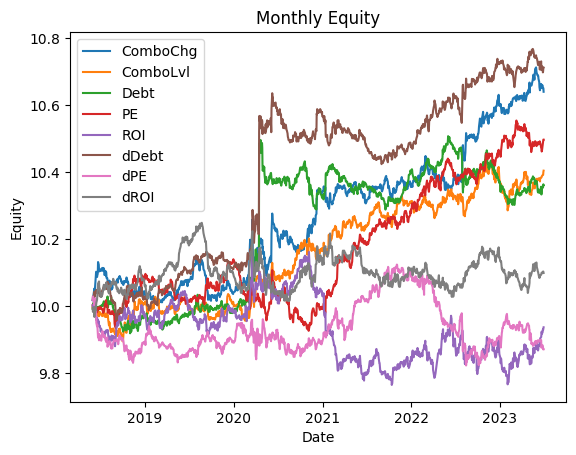

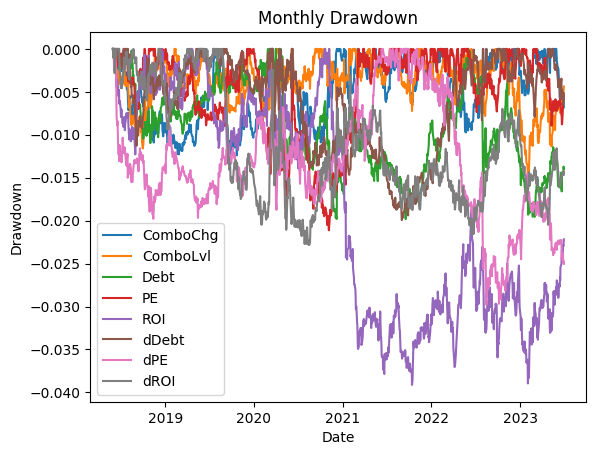

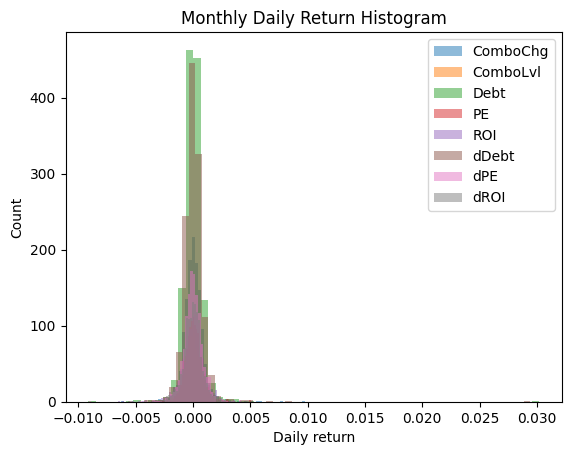

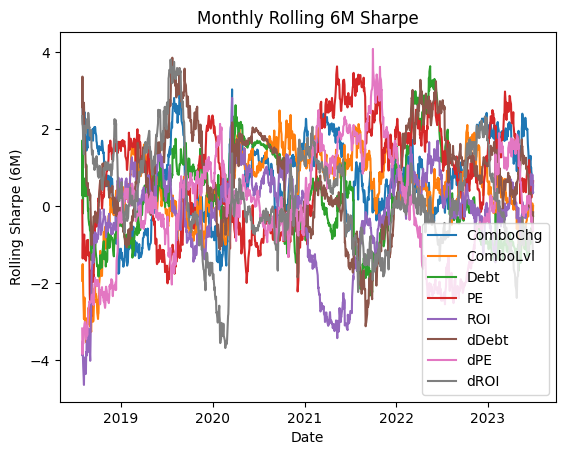

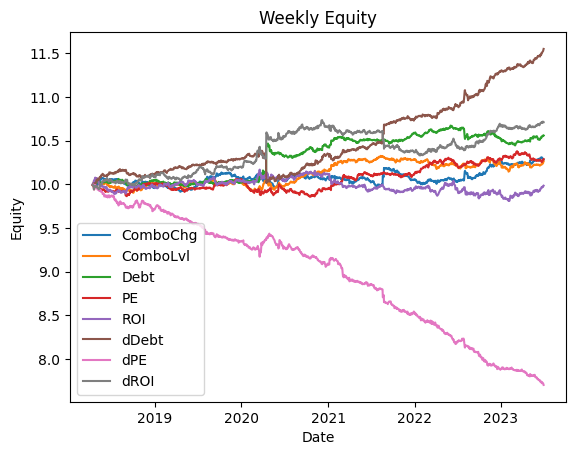

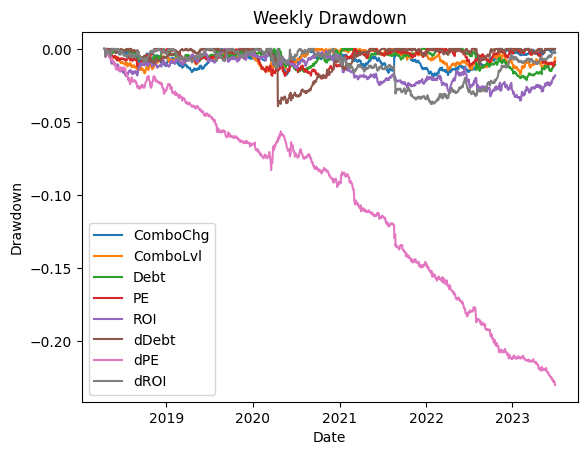

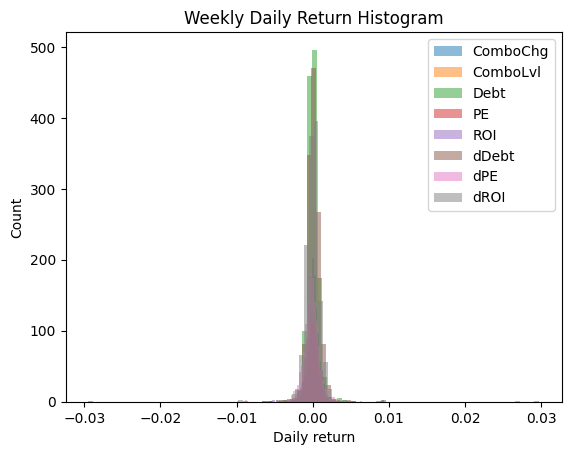

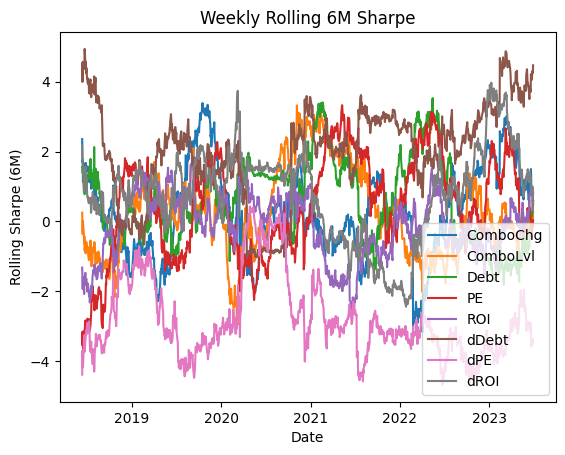

In [92]:
def plot_bundle(eqdf, rdf, title_prefix):
    plt.figure()
    for strat in sorted(eqdf["strategy"].unique()):
        e = eqdf[eqdf["strategy"] == strat].set_index("date")["equity"].sort_index()
        plt.plot(e.index, e.values, label=strat)
    plt.title(f"{title_prefix} Equity")
    plt.xlabel("Date")
    plt.ylabel("Equity")
    plt.legend()
    plt.show()

    plt.figure()
    for strat in sorted(eqdf["strategy"].unique()):
        e = eqdf[eqdf["strategy"] == strat].set_index("date")["equity"].sort_index()
        _, dd = max_drawdown(e)
        plt.plot(dd.index, dd.values, label=strat)
    plt.title(f"{title_prefix} Drawdown")
    plt.xlabel("Date")
    plt.ylabel("Drawdown")
    plt.legend()
    plt.show()

    plt.figure()
    for strat in sorted(rdf["strategy"].unique()):
        r = rdf[rdf["strategy"] == strat].set_index("date")["ret"].sort_index()
        plt.hist(r.dropna().values, bins=60, alpha=0.5, label=strat)
    plt.title(f"{title_prefix} Daily Return Histogram")
    plt.xlabel("Daily return")
    plt.ylabel("Count")
    plt.legend()
    plt.show()

    plt.figure()
    for strat in sorted(rdf["strategy"].unique()):
        r = rdf[rdf["strategy"] == strat].set_index("date")["ret"].sort_index()
        rs = rolling_sharpe(r, window=126)
        plt.plot(rs.index, rs.values, label=strat)
    plt.title(f"{title_prefix} Rolling 6M Sharpe")
    plt.xlabel("Date")
    plt.ylabel("Rolling Sharpe (6M)")
    plt.legend()
    plt.show()

plot_bundle(eqM, rM, "Monthly")
plot_bundle(eqW, rW, "Weekly")

### 5.8 Sign robustness check for the price to earnings change signal
The weekly price to earnings change signal performs poorly under the baseline sign. I rerun the weekly backtest after flipping the sign to test whether the issue is purely directional. The flip reverses the performance and improves the combined signal while debt to market cap and return on investment are unchanged which confirms the test only touches the price to earnings component. My interpretation is that at weekly horizons rising price to earnings is associated with positive performance in this sample so the naive value sign is not robust. I keep the baseline specification in the main results and report the flip as a sensitivity check.

In [93]:
def build_signals_pe_flip(lookback: int):
    d_debt = rat_debt - rat_debt.shift(lookback)
    d_roi  = rat_roi  - rat_roi.shift(lookback)
    d_pe   = rat_pe   - rat_pe.shift(lookback)

    s_debt = (-d_debt)
    s_roi  = ( d_roi)

    s_pe_orig = (-d_pe)
    s_pe_flip = ( d_pe)

    s_combo_orig = pd.DataFrame(index=s_roi.index, columns=s_roi.columns, dtype=float)
    s_combo_flip = pd.DataFrame(index=s_roi.index, columns=s_roi.columns, dtype=float)

    for dt in s_roi.index:
        v_roi = s_roi.loc[dt]
        v_pe_o = s_pe_orig.loc[dt]
        v_pe_f = s_pe_flip.loc[dt]
        v_debt = s_debt.loc[dt]

        z_roi = zscore_cross_section(v_roi)
        z_debt = zscore_cross_section(v_debt)
        z_pe_o = zscore_cross_section(v_pe_o)
        z_pe_f = zscore_cross_section(v_pe_f)

        s_combo_orig.loc[dt] = (z_roi + z_pe_o + z_debt) / 3.0
        s_combo_flip.loc[dt] = (z_roi + z_pe_f + z_debt) / 3.0

    return (
        {"dROI": s_roi, "dPE": s_pe_orig, "dDebt": s_debt, "Combo": s_combo_orig},
        {"dROI": s_roi, "dPE": s_pe_flip, "dDebt": s_debt, "Combo": s_combo_flip},
    )

signalsW_orig, signalsW_flip = build_signals_pe_flip(lookback=5)

eqW_o, rW_o, gW_o, lW_o, sW_o, metaW_o = run_backtest(signalsW_orig, freq="W", lookback=5, funding_rate_annual=0.05)
eqW_f, rW_f, gW_f, lW_f, sW_f, metaW_f = run_backtest(signalsW_flip, freq="W", lookback=5, funding_rate_annual=0.05)

sumW_o = summarize(eqW_o, rW_o).set_index("strategy")[["ann_return","ann_vol","sharpe","max_drawdown"]]
sumW_f = summarize(eqW_f, rW_f).set_index("strategy")[["ann_return","ann_vol","sharpe","max_drawdown"]]

cmp = sumW_o.join(sumW_f, lsuffix="_orig", rsuffix="_PEflipped")
cmp["sharpe_change"] = cmp["sharpe_PEflipped"] - cmp["sharpe_orig"]
cmp["ann_return_change"] = cmp["ann_return_PEflipped"] - cmp["ann_return_orig"]
display(cmp.sort_values("sharpe_change", ascending=False))

display(final_pl(eqW_o, metaW_o).set_index("strategy")[["final_equity","PL","PL_over_traded_notional"]].rename(columns=lambda c: c+"_orig").join(
    final_pl(eqW_f, metaW_f).set_index("strategy")[["final_equity","PL","PL_over_traded_notional"]].rename(columns=lambda c: c+"_PEflipped")
).reset_index())

,ann_return_orig,ann_vol_orig,sharpe_orig,max_drawdown_orig,ann_return_PEflipped,ann_vol_PEflipped,sharpe_PEflipped,max_drawdown_PEflipped,sharpe_change,ann_return_change
strategy,,,,,,,,,,
dPE,-0.048886,0.018307,-2.670414,-0.229800,0.049993,0.018271,2.736218,-0.028278,5.406631,0.098879
Combo,0.005375,0.014915,0.360401,-0.018541,0.039517,0.017262,2.289217,-0.031977,1.928817,0.034141
dDebt,0.028082,0.020002,1.403969,-0.039157,0.028082,0.020002,1.403969,-0.039157,0.000000,0.000000
dROI,0.013284,0.019721,0.673594,-0.037623,0.013284,0.019721,0.673594,-0.037623,0.000000,0.000000


,strategy,final_equity_orig,PL_orig,PL_over_traded_notional_orig,final_equity_PEflipped,PL_PEflipped,PL_over_traded_notional_PEflipped
0,dDebt,11.552273,1.552273,0.000899,11.552273,1.552273,0.000836
1,Combo,10.283266,0.283266,0.000164,12.237628,2.237628,0.001205
2,dPE,7.701655,-2.298345,-0.001330,12.893997,2.893997,0.001559
3,dROI,10.711759,0.711759,0.000412,10.711759,0.711759,0.000383


## Deeper analysis: interpretation, robustness, and implementation notes

I add three short checks beyond the baseline equity curves and summary tables:

1) **Mechanism / intuition:** why each ratio should (or should not) forecast returns, and why weekly vs monthly can behave differently.
2) **Robustness:** performance by subperiod and whether results are driven by a narrow slice of time.
3) **Implementation realism:** turnover/cost sensitivity and a few practical constraints (shorting, capacity, staleness).

### 1) Economic intuition (levels vs changes)

- **ROI (level):** a standard “quality/profitability” signal. If it works, I expect steadier performance and less sensitivity to rebalancing frequency.
- **P/E (level):** a classic value signal. Weak/unstable performance at weekly frequency is plausible because short-horizon returns can be dominated by momentum and microstructure effects rather than valuation convergence.
- **Debt-to-market-cap (level):** a leverage/distress proxy. If it works, it may reflect compensation for funding risk, default risk, or equity issuance/financial distress channels.

For **changes**, the interpretation is different: ΔP/E can be mechanically driven by recent price moves and earnings updates (denominator effects), so the sign can flip depending on whether the short horizon is closer to a momentum signal than a valuation signal.

In [94]:
def summarize_subset(eqdf, rdf, start, end):
    eq_sub = eqdf[(eqdf["date"] >= start) & (eqdf["date"] <= end)].copy()
    r_sub = rdf[(rdf["date"] >= start) & (rdf["date"] <= end)].copy()
    if len(r_sub) == 0:
        return None
    return summarize(eq_sub, r_sub)

subperiods = [
    ("2018-01-01", "2019-12-31", "2018–2019"),
    ("2020-01-01", "2020-12-31", "2020"),
    ("2021-01-01", "2022-12-31", "2021–2022"),
    ("2023-01-01", "2023-06-30", "2023H1"),
]

for start, end, label in subperiods:
    sm = summarize_subset(eqM, rM, pd.Timestamp(start), pd.Timestamp(end))
    sw = summarize_subset(eqW, rW, pd.Timestamp(start), pd.Timestamp(end))
    print(f"\n--- Subperiod: {label} ---")
    if sm is not None:
        display(pretty_summary(sm).set_index("strategy")[["ann_return","ann_vol","sharpe","max_drawdown"]].sort_values("sharpe", ascending=False))
    if sw is not None:
        display(pretty_summary(sw).set_index("strategy")[["ann_return","ann_vol","sharpe","max_drawdown"]].sort_values("sharpe", ascending=False))


--- Subperiod: 2018–2019 ---


,ann_return,ann_vol,sharpe,max_drawdown
strategy,,,,
PE,0.009,0.010,0.862,-0.009
dDebt,0.007,0.010,0.690,-0.011
dROI,0.006,0.011,0.523,-0.017
ComboChg,0.003,0.011,0.243,-0.012
ComboLvl,0.001,0.011,0.061,-0.012
ROI,-0.001,0.013,-0.098,-0.013
Debt,-0.001,0.010,-0.118,-0.011
dPE,-0.007,0.011,-0.606,-0.020


,ann_return,ann_vol,sharpe,max_drawdown
strategy,,,,
dDebt,0.017,0.011,1.597,-0.010
dROI,0.012,0.013,0.861,-0.009
PE,0.004,0.010,0.345,-0.013
ComboChg,0.004,0.012,0.324,-0.016
ROI,0.002,0.014,0.136,-0.019
Debt,0.001,0.010,0.127,-0.010
ComboLvl,0.001,0.011,0.126,-0.017
dPE,-0.038,0.015,-2.593,-0.067



--- Subperiod: 2020 ---


,ann_return,ann_vol,sharpe,max_drawdown
strategy,,,,
ComboChg,0.030,0.021,1.420,-0.016
dDebt,0.045,0.035,1.288,-0.014
ComboLvl,0.016,0.014,1.099,-0.007
Debt,0.035,0.035,1.008,-0.020
ROI,0.005,0.019,0.256,-0.014
dROI,0.003,0.018,0.150,-0.020
dPE,-0.000,0.016,-0.011,-0.012
PE,-0.014,0.015,-0.969,-0.021


...

,ann_return,ann_vol,sharpe,max_drawdown
strategy,,,,
PE,0.023,0.012,1.945,-0.007
ComboChg,0.013,0.014,0.899,-0.010
ComboLvl,0.010,0.012,0.857,-0.008
dDebt,0.007,0.013,0.590,-0.014
Debt,0.002,0.013,0.161,-0.016
dROI,0.001,0.012,0.098,-0.019
dPE,0.001,0.015,0.038,-0.030
ROI,-0.009,0.017,-0.525,-0.027


,ann_return,ann_vol,sharpe,max_drawdown
strategy,,,,
dDebt,0.045,0.018,2.554,-0.010
PE,0.017,0.012,1.368,-0.012
ComboChg,0.008,0.017,0.457,-0.019
Debt,0.004,0.012,0.358,-0.015
ComboLvl,0.003,0.012,0.279,-0.015
dROI,0.001,0.017,0.051,-0.032
ROI,-0.011,0.016,-0.699,-0.028
dPE,-0.069,0.021,-3.295,-0.140



--- Subperiod: 2023H1 ---


,ann_return,ann_vol,sharpe,max_drawdown
strategy,,,,
ROI,0.017,0.016,1.054,-0.008
PE,0.008,0.012,0.704,-0.009
ComboChg,0.007,0.011,0.646,-0.007
ComboLvl,0.005,0.013,0.417,-0.008
dDebt,-0.002,0.011,-0.208,-0.007
Debt,-0.002,0.011,-0.218,-0.006
dPE,-0.007,0.012,-0.595,-0.011
dROI,-0.010,0.011,-0.875,-0.009


,ann_return,ann_vol,sharpe,max_drawdown
strategy,,,,
dDebt,0.047,0.010,4.570,-0.003
ROI,0.021,0.016,1.311,-0.006
ComboChg,0.008,0.011,0.743,-0.004
dROI,0.007,0.010,0.734,-0.005
ComboLvl,0.008,0.013,0.614,-0.007
Debt,0.007,0.011,0.595,-0.006
PE,0.001,0.012,0.067,-0.012
dPE,-0.045,0.013,-3.439,-0.025


In [95]:
def pivot_returns(rdf):
    return rdf.pivot(index="date", columns="strategy", values="ret").sort_index()

rM_p = pivot_returns(rM)
rW_p = pivot_returns(rW)

corrM = rM_p.corr()
corrW = rW_p.corr()

print("Monthly strategy return correlation:")
display(corrM.round(2))

print("Weekly strategy return correlation:")
display(corrW.round(2))

Monthly strategy return correlation:


strategy,ComboChg,ComboLvl,Debt,PE,ROI,dDebt,dPE,dROI
strategy,,,,,,,,
ComboChg,1.00,0.26,-0.00,0.08,0.17,0.38,0.06,0.42
ComboLvl,0.26,1.00,0.27,0.31,0.57,0.14,0.00,0.23
Debt,-0.00,0.27,1.00,0.09,0.13,0.59,0.03,0.10
PE,0.08,0.31,0.09,1.00,0.11,0.04,0.09,0.01
ROI,0.17,0.57,0.13,0.11,1.00,0.06,-0.08,0.27
dDebt,0.38,0.14,0.59,0.04,0.06,1.00,-0.19,0.15
dPE,0.06,0.00,0.03,0.09,-0.08,-0.19,1.00,-0.11
dROI,0.42,0.23,0.10,0.01,0.27,0.15,-0.11,1.00


Weekly strategy return correlation:


strategy,ComboChg,ComboLvl,Debt,PE,ROI,dDebt,dPE,dROI
strategy,,,,,,,,
ComboChg,1.00,0.05,-0.08,0.15,-0.01,0.32,-0.03,0.14
ComboLvl,0.05,1.00,0.26,0.38,0.56,0.02,-0.06,0.10
Debt,-0.08,0.26,1.00,0.09,0.10,-0.46,0.03,0.48
PE,0.15,0.38,0.09,1.00,0.16,0.02,0.05,0.09
ROI,-0.01,0.56,0.10,0.16,1.00,-0.01,-0.06,0.10
dDebt,0.32,0.02,-0.46,0.02,-0.01,1.00,-0.38,-0.46
dPE,-0.03,-0.06,0.03,0.05,-0.06,-0.38,1.00,-0.02
dROI,0.14,0.10,0.48,0.09,0.10,-0.46,-0.02,1.00


In [96]:
def estimate_traded_notional(signals: dict, freq: str, lookback: int, cap0_override=None):
    rb = rebalance_dates(freq)
    rb = rb[rb >= (rets.index.min() + pd.Timedelta(days=lookback * 2))]
    if len(rb) < 6:
        raise ValueError("Not enough rebalance dates after lookback.")
    if cap0_override is None:
        first_rb = None
        cap0 = None
        for cand in rb[:80]:
            first_gross = {}
            for name, mat in signals.items():
                row = mat.loc[cand] if cand in mat.index else mat.loc[:cand].iloc[-1]
                p = make_positions_vigintile(row, gross_total=1.0)
                first_gross[name] = float(p.abs().sum())
            g0 = float(np.nanmedian(list(first_gross.values())))
            if np.isfinite(g0) and g0 > 0:
                first_rb = cand
                cap0 = 10.0 * g0
                break
        if cap0 is None:
            raise ValueError("Could not form initial positions for turnover estimate.")
    else:
        cap0 = float(cap0_override)

    cap_by_strat = {name: cap0 for name in signals.keys()}
    pos_prev = {name: pd.Series(0.0, index=rets.columns) for name in signals.keys()}
    traded = {name: 0.0 for name in signals.keys()}

    for t0 in rb:
        for name, mat in signals.items():
            row = mat.loc[t0] if t0 in mat.index else mat.loc[:t0].iloc[-1]
            gross_total = cap_by_strat[name] / 10.0
            pos = make_positions_vigintile(row, gross_total=gross_total)

            traded[name] += float((pos - pos_prev[name]).abs().sum())
            pos_prev[name] = pos

    return cap0, traded

def cost_sensitivity(eqdf, meta, traded_by_strat, bps_list=(0, 5, 10, 20)):
    last_eq = eqdf.sort_values("date").groupby("strategy").tail(1).set_index("strategy")["equity"]
    cap0 = float(meta["cap0"])
    out_rows = []
    for strat, eq_last in last_eq.items():
        traded = traded_by_strat.get(strat, np.nan)
        for bps in bps_list:
            cost = (bps / 10000.0) * traded if np.isfinite(traded) else np.nan
            net_eq = eq_last - cost if np.isfinite(cost) else np.nan
            out_rows.append((strat, bps, traded, cost, net_eq))
    out = pd.DataFrame(out_rows, columns=["strategy","cost_bps","traded_notional","cost_dollars","net_final_equity"])
    out["cost_dollars"] = out["cost_dollars"].round(3)
    out["net_final_equity"] = out["net_final_equity"].round(3)
    out["traded_notional"] = out["traded_notional"].round(3)
    return out

# Monthly
signals_M = build_signals(lookback=21)
cap0_M, traded_M = estimate_traded_notional(signals_M, freq="M", lookback=21)
eqM2, rM2, gM2, lM2, sM2, metaM2 = run_backtest(signals_M, freq="M", lookback=21, funding_rate_annual=0.05)

print("Monthly cost sensitivity (simple bps per $ traded):")
display(cost_sensitivity(eqM2, metaM2, traded_M).sort_values(["strategy","cost_bps"]))

# Weekly
signals_W = build_signals(lookback=5)
cap0_W, traded_W = estimate_traded_notional(signals_W, freq="W", lookback=5)
eqW2, rW2, gW2, lW2, sW2, metaW2 = run_backtest(signals_W, freq="W", lookback=5, funding_rate_annual=0.05)

print("Weekly cost sensitivity (simple bps per $ traded):")
display(cost_sensitivity(eqW2, metaW2, traded_W).sort_values(["strategy","cost_bps"]))

Monthly cost sensitivity (simple bps per $ traded):


,strategy,cost_bps,traded_notional,cost_dollars,net_final_equity
20,ComboChg,0,109.309,0.000,10.641
21,ComboChg,5,109.309,0.055,10.586
22,ComboChg,10,109.309,0.109,10.531
23,ComboChg,20,109.309,0.219,10.422
16,ComboLvl,0,38.155,0.000,10.405
17,ComboLvl,5,38.155,0.019,10.386
18,ComboLvl,10,38.155,0.038,10.367
19,ComboLvl,20,38.155,0.076,10.328
12,Debt,0,28.027,0.000,10.361
13,Debt,5,28.027,0.014,10.347


Weekly cost sensitivity (simple bps per $ traded):


,strategy,cost_bps,traded_notional,cost_dollars,net_final_equity
20,ComboChg,0,448.385,0.000,10.283
21,ComboChg,5,448.385,0.224,10.059
22,ComboChg,10,448.385,0.448,9.835
23,ComboChg,20,448.385,0.897,9.386
16,ComboLvl,0,62.773,0.000,10.265
17,ComboLvl,5,62.773,0.031,10.233
18,ComboLvl,10,62.773,0.063,10.202
19,ComboLvl,20,62.773,0.126,10.139
12,Debt,0,44.676,0.000,10.561
13,Debt,5,44.676,0.022,10.538


### 2) Implementation considerations and extensions

- **Transaction costs / capacity:** weekly rebalancing is much more exposed to costs; even a small bps-per-dollar model can change rankings.
- **Shorting / borrow:** short legs can face borrow constraints and fees; strategies that rely heavily on the short book should be stress-tested under higher financing frictions.
- **Staleness / filing timing:** the ratio updates only at filings. If the strategy is rebalanced weekly, many weeks may reuse stale signal values; that can interact with momentum and make “change” signals behave unexpectedly.
- **Signal engineering extensions:** winsorization, cross-sectional ranking with sector neutrality, and alternative combo weights (e.g., risk-parity weights by signal volatility) are natural next steps.

### Deeper analysis: regime dependence, diversification, and cost sensitivity

**Subperiod stability.** Performance is not uniform across time. Monthly results show that signals can rotate: for example, some “change” signals perform well in 2018–2019 but look weaker in 2021–2022, while the P/E *level* signal becomes comparatively stronger in 2021–2022 and 2023H1. Weekly results are even more regime-sensitive, which is consistent with higher turnover and less time for valuation-based signals to mean-revert.

**Weekly ΔP/E sign.** The weekly dPE strategy is consistently negative across multiple subperiods, suggesting that short-horizon ΔP/E behaves more like a mechanically price-driven signal than “valuation reversion.” Since P/E changes at short horizons are often dominated by price moves (and earnings updates are sparse and lumpy), the weekly signal can act like an unintended momentum/anti-momentum proxy, which explains the sign instability relative to the level-based P/E signal.

**Diversification and the Combo construction.** The correlation matrices indicate that ComboLvl is fairly correlated with the underlying level signals (especially ROI and PE), so the combo’s incremental benefit is limited when one component dominates. In contrast, the weekly ComboChg appears less correlated with the level strategies, so it can provide genuine diversification across “style” dimensions (levels vs changes) rather than simply averaging similar signals.

**Implementation realism: turnover / cost sensitivity.** The traded-notional proxy confirms that change-based signals, especially at weekly rebalancing, trade substantially more than level-based signals. Even under a simple bps-per-dollar model, higher turnover mechanically reduces net performance and can change rankings. In practice, this effect would likely be larger once bid–ask spreads, market impact, and short-borrow frictions are included, so strategies with high turnover (weekly change signals) should be treated as more fragile.

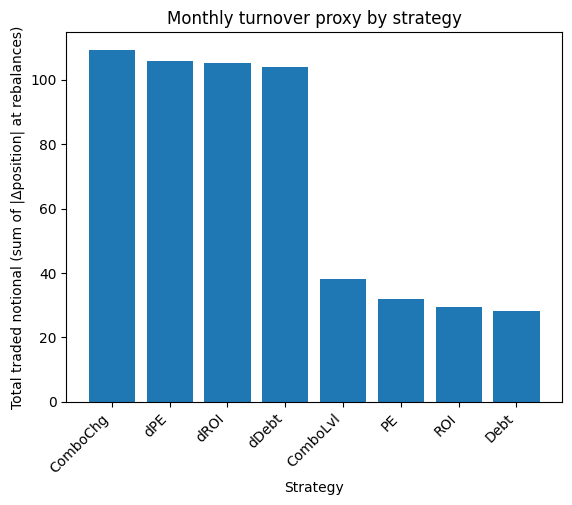

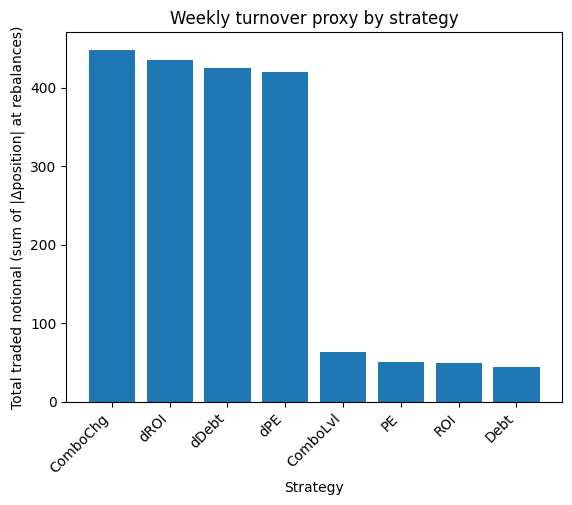

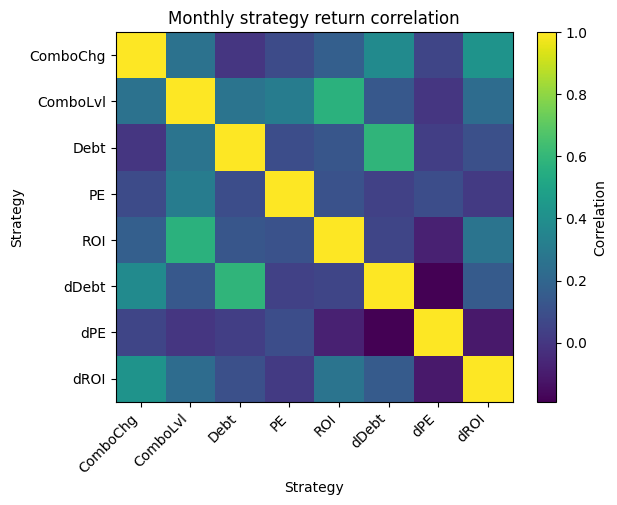

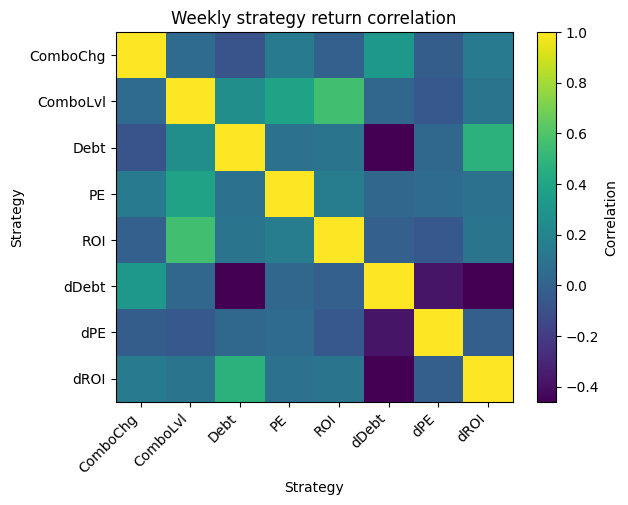

In [97]:
def plot_traded_notional(traded_dict, title):
    s = pd.Series(traded_dict).sort_values(ascending=False)
    plt.figure()
    plt.bar(s.index, s.values)
    plt.title(title)
    plt.xlabel("Strategy")
    plt.ylabel("Total traded notional (sum of |Δposition| at rebalances)")
    plt.xticks(rotation=45, ha="right")
    plt.show()

plot_traded_notional(traded_M, "Monthly turnover proxy by strategy")
plot_traded_notional(traded_W, "Weekly turnover proxy by strategy")

def plot_corr_heatmap(corr, title):
    mat = corr.values
    plt.figure()
    plt.imshow(mat, aspect="auto")
    plt.title(title)
    plt.xlabel("Strategy")
    plt.ylabel("Strategy")
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
    plt.yticks(range(len(corr.index)), corr.index)
    plt.colorbar(label="Correlation")
    plt.show()

plot_corr_heatmap(corrM.round(2), "Monthly strategy return correlation")
plot_corr_heatmap(corrW.round(2), "Weekly strategy return correlation")